In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Bidirectional, LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

import bz2
import csv
import re

**Loading Datasets**

In [2]:
import kagglehub
import bz2
import os

# Download the latest version of the Amazon Reviews dataset
path = kagglehub.dataset_download("bittlingmayer/amazonreviews")

print("Dataset path:", path)
print("Files in dataset folder:")
print(os.listdir(path))


# Paths to train and test files
train_path = os.path.join(path, "train.ft.txt.bz2")
test_path = os.path.join(path, "test.ft.txt.bz2")


# Load a subset of training data
with bz2.BZ2File(train_path, "r") as f:
    training_data = [
        f.readline().decode("utf-8").strip()
        for _ in range(12000)
    ]


# Load a subset of test data
with bz2.BZ2File(test_path, "r") as f:
    test_data = [
        f.readline().decode("utf-8").strip()
        for _ in range(2500)
    ]


print("Training data subset size:", len(training_data))
print("Test data subset size:", len(test_data))



Using Colab cache for faster access to the 'amazonreviews' dataset.
Dataset path: /kaggle/input/amazonreviews
Files in dataset folder:
['test.ft.txt.bz2', 'train.ft.txt.bz2']
Training data subset size: 12000
Test data subset size: 2500


**Preparing Dataset**

In [3]:
training_data[0:5]

['__label__2 Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^',
 "__label__2 The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",
 '__label__2 Amazing!: This sound

In [4]:
# Split the data into labels and texts
training_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in training_data]
training_texts = [re.sub(r'__label__\d ', '', line) for line in training_data]

test_labels = [int(re.findall(r'__label__(\d)', line)[0]) for line in test_data]
test_texts = [re.sub(r'__label__\d ', '', line) for line in test_data]

# Convert labels to binary (0 and 1)
training_labels = [0 if label == 1 else 1 for label in training_labels]
test_labels = [0 if label == 1 else 1 for label in test_labels]

In [5]:
test_labels[:20]

[1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1]

In [6]:
print(test_labels[:4])
print("\n\n",test_texts[:4])

[1, 1, 0, 1]


 ['Great CD: My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I\'m in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life\'s hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing "Who was that singing ?"', "One of the best game music soundtracks - for a game I didn't really play: Despite the fact that I have only played a small portion of the game, the music I heard (plus the connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of t

**Text Cleaning**

In [7]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

def clean_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    # Convert to lowercase
    text = text.lower()

    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]

    # Join words back into a string
    return " ".join(words)

# Apply function to training and test texts
training_texts = [clean_text(text) for text in training_texts]
test_texts = [clean_text(text) for text in test_texts]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
training_texts[0]

'stune even nongam sound track beauti paint seneri mind well would recomend even peopl hate vid game music play game chrono cross game ever play best music back away crude keyboard take fresher step grate guitar soul orchestra would impress anyon care listen'

**Tokenization**

In [9]:
# Tokenization and padding
max_words = 1000
max_sequence_length = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(training_texts)

X_train = tokenizer.texts_to_sequences(training_texts)
X_test = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=max_sequence_length)
X_test = pad_sequences(X_test, maxlen=max_sequence_length)

In [10]:
X_train = np.array(X_train)
print(X_train.shape)
X_test = np.array(X_test)
print(X_test.shape)
y_train = np.array(training_labels)
print(y_train.shape)
y_test = np.array(test_labels)
print(y_test.shape)

(12000, 100)
(2500, 100)
(12000,)
(2500,)


**Training RNN**

In [11]:
# Define improved RNN model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    SimpleRNN(128, return_sequences=True, dropout=0.3),  # RNN layer with dropout
    LayerNormalization(),  # Added normalization for stability
    SimpleRNN(128, dropout=0.3),  # Second RNN layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 352ms/step - accuracy: 0.5092 - loss: 0.8640 - val_accuracy: 0.4900 - val_loss: 0.7305
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5118 - loss: 0.7974 - val_accuracy: 0.5004 - val_loss: 0.7028
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5011 - loss: 0.7759 - val_accuracy: 0.5008 - val_loss: 0.6992
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5068 - loss: 0.7536 - val_accuracy: 0.5188 - val_loss: 0.6932
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5088 - loss: 0.7401 - val_accuracy: 0.5292 - val_loss: 0.6909
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5052 - loss: 0.7383 - val_accuracy: 0.5212 - val_loss: 0.6905
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5113 - loss: 0.7289 - val_accuracy: 0.5392 - val_loss: 0.6889
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5075 - loss: 0.7241 - val_accuracy: 0.5204 -

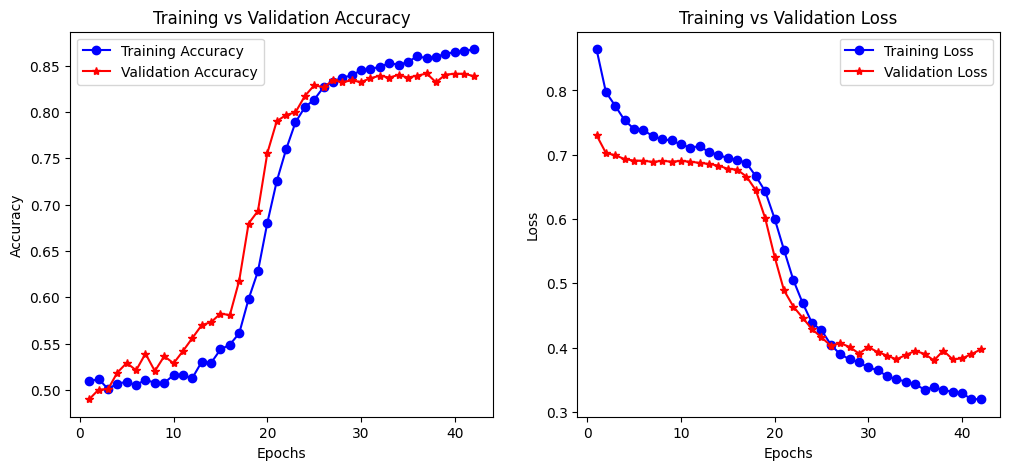

In [12]:

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [13]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Confusion Matrix:
[[ 971  220]
 [ 176 1133]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1191
           1       0.84      0.87      0.85      1309

    accuracy                           0.84      2500
   macro avg       0.84      0.84      0.84      2500
weighted avg       0.84      0.84      0.84      2500



**Training LSTM**

In [14]:
# Define improved model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.2)),  # Added recurrent dropout
    LayerNormalization(),  # Added normalization for stability
    Dropout(0.3),
    Bidirectional(LSTM(128, recurrent_dropout=0.2)),
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5060 - loss: 0.7555 - val_accuracy: 0.5768 - val_loss: 0.6784
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5506 - loss: 0.6946 - val_accuracy: 0.6100 - val_loss: 0.6664
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.6025 - loss: 0.6625 - val_accuracy: 0.6676 - val_loss: 0.6313
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6497 - loss: 0.6220 - val_accuracy: 0.7100 - val_loss: 0.5734
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.7093 - loss: 0.5634 - val_accuracy: 0.7456 - val_loss: 0.5173
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7584 - loss: 0.5035 - val_accuracy: 0.7692 - val_loss: 0.4783
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.7840 - loss: 0.4625 - val_accuracy: 0.7820 - val_loss: 0.4539
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8081 - loss: 0.4230 - val_accuracy: 0.7984 - val_loss: 0.4339
Epo

**Model Evaluation**

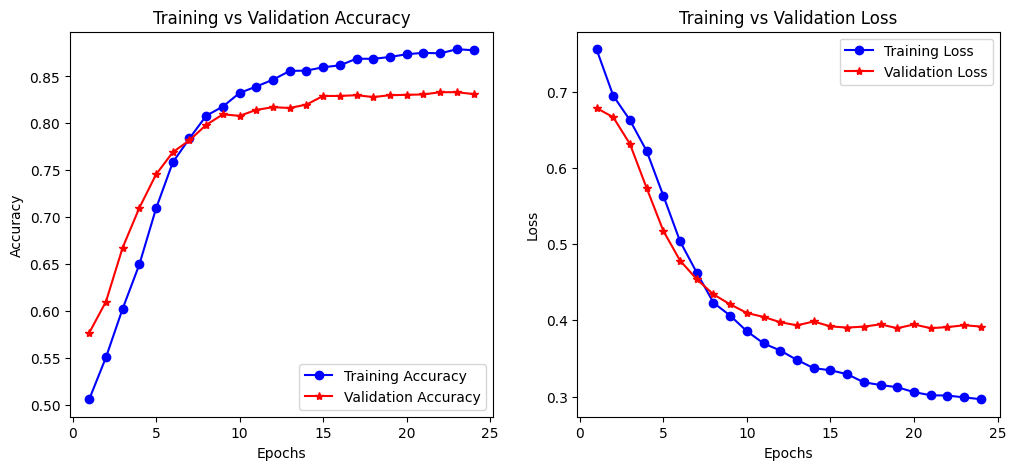

In [15]:
import matplotlib.pyplot as plt

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [16]:
# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 269ms/step
Confusion Matrix:
[[ 955  236]
 [ 189 1120]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1191
           1       0.83      0.86      0.84      1309

    accuracy                           0.83      2500
   macro avg       0.83      0.83      0.83      2500
weighted avg       0.83      0.83      0.83      2500



**Training GRU**

Epoch 1/50


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 720ms/step - accuracy: 0.5073 - loss: 0.8530 - val_accuracy: 0.5828 - val_loss: 0.6921
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 695ms/step - accuracy: 0.5433 - loss: 0.7724 - val_accuracy: 0.6140 - val_loss: 0.6561
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 688ms/step - accuracy: 0.5658 - loss: 0.7380 - val_accuracy: 0.6304 - val_loss: 0.6403
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 704ms/step - accuracy: 0.5764 - loss: 0.7178 - val_accuracy: 0.6416 - val_loss: 0.6298
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 676ms/step - accuracy: 0.5956 - loss: 0.6914 - val_accuracy: 0.6552 - val_loss: 0.6190
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 697ms/step - accuracy: 0.6124 - loss: 0.6708 - val_accuracy: 0.6644 - val_loss: 0.6094
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 684ms/step - accuracy: 0.6143 - loss: 0.6640 - val_accuracy: 0.6728 - val_loss: 0.6011
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 720ms/step - accuracy: 0.6405 - loss: 0.6382 - val_accuracy: 0.679

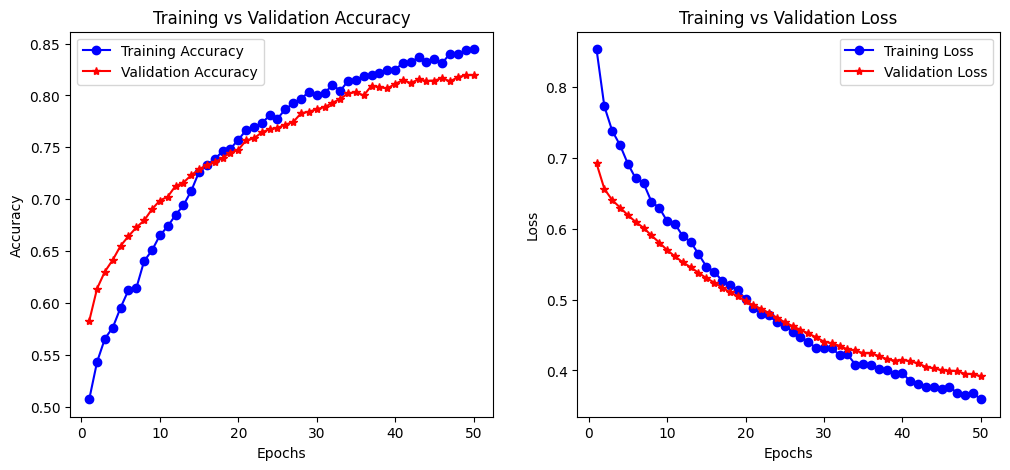

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step
Confusion Matrix:
[[ 928  263]
 [ 188 1121]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      1191
           1       0.81      0.86      0.83      1309

    accuracy                           0.82      2500
   macro avg       0.82      0.82      0.82      2500
weighted avg       0.82      0.82      0.82      2500



In [17]:
# Define improved GRU model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_sequence_length),  # Increased embedding size
    GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),  # GRU layer with dropout
    LayerNormalization(),  # Added normalization for stability
    GRU(128, dropout=0.3, recurrent_dropout=0.2),  # Second GRU layer
    LayerNormalization(),
    Dropout(0.3),
    Dense(64, activation="relu"),  # Extra dense layer
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile with lower learning rate
model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=512, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)

# Extract values from history
epochs = range(1, len(history.history['accuracy']) + 1)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()



# Evaluate with a confusion matrix and classification report
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

**Detection System**

In [18]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(text, model, tokenizer, max_sequence_length=100):
    # clean text
    text = clean_text(text)
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])

    # Pad sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length)

    # Predict sentiment
    prediction = model.predict(padded_sequence)[0][0]  # Extract scalar value

    # Determine sentiment
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😡"

    return sentiment, float(prediction)

# Example usage:
test_sentences = [
    "I love this product! It's amazing.",
    "This is the worst service I have ever experienced.",
    "The movie was okay, not great but not terrible either."
]

for sentence in test_sentences:
    sentiment, confidence = predict_sentiment(sentence, model, tokenizer)
    print(f"Text: {sentence}\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Text: I love this product! It's amazing.
Predicted Sentiment: Positive 😊 (Confidence: 0.9909)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Text: This is the worst service I have ever experienced.
Predicted Sentiment: Negative 😡 (Confidence: 0.0020)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Text: The movie was okay, not great but not terrible either.
Predicted Sentiment: Negative 😡 (Confidence: 0.4136)



In [20]:
model.save("lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [21]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [22]:
import tensorflow as tf
print(tf.__version__)

2.20.0
